

# Segmental parameters for obese_class I,II
A system of axes has been defined for each segment, with an origin at the segment mass center, while axes have been aligned with approximate body axes: anteroposterior (x), vertical (y), and mediolateral (z). The corresponding result for the position of the mass center for the head and hand is measured at the center and the center of mass for the thigh is measured from the upper cross section of the thigh lower part, The other segments are measured from the upper cross section of each segment. The measurements are taken with positive values indicating anterior (forward), upward, and lateral (sideways) directions.


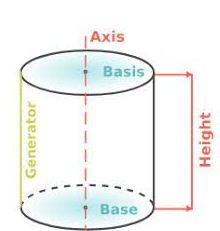

Upper torso (Frustum of right elliptical cone + Reverted frustum of right elliptical cone)

Middle torso (Reverted frustum of right elliptical cone)

Lower torso (Frustum of right elliptical cone + reverted elliptical cone)

Thigh  (Biased cone + Frustum of cone) 

Shank (Frustum of cone)

Foot (Frustum of cone)

Upper arm (Frustum of cone)

Lower arm (Frustum of cone)

Hand (Sphere)

# Segmental parameters for obese_class III
A system of axes has been defined for each segment, with an origin at the segment mass center, while axes have been aligned with approximate body axes: sagittal (x), longitudinal (y), and frontal (z).


Head+Neck (Ellipsoid)

Upper torso (Frustum of right elliptical cone + Reverted frustum of right elliptical cone)

Middle torso (right Frustum of cone or  Reverted right Frustum of cone based on Waist circumference)

Lower torso (right Frustum of cone + reverted cone)

Thigh (Biased cone + Frustum of cone) 

Shank (Frustum of cone)

Foot (Frustum of cone)

Upper arm (Frustum of cone)

Lower arm (Frustum of cone)

Hand (Sphere)

In [85]:
# Import Necessary Modules
import glob
import matplotlib.pyplot as plt 
from skimage import io
import numpy as np
import math
%matplotlib inline 

## 1. Head+Neck (Sphere)



Input parameters: Head_length + head_mass

In [142]:
head_circumference_base=57.33
head_length=24.29305825

head_mass_base = 5.070034541
head_mass_obese = 6.070034541
head_circumference_obese=head_circumference_base*(head_mass_obese/head_mass_base)


# Ellipsoid parameters for head and neck
a = head_circumference_obese/(2 * np.pi) # Head circumference
b = head_circumference_obese/(2 * np.pi) # Head circumference
c = head_length/2 # Head length

# Volume of ellipsoid
volume_head = (4/3) * np.pi * a * b * c

# Center of mass of ellipsoid (at the center)
center_of_mass_head_obese_Y =  0
center_of_mass_head_obese_X =  0
center_of_mass_head_obese_Z =  0
# Inertia of ellipsoid

Ixx_head_obese = (1/5) * head_mass_obese * (a**2 + c**2)
Iyy_head_obese = (1/5) * head_mass_obese * (a**2 + b**2)
Izz_head_obese = (1/5) * head_mass_obese * (b**2 + c**2)

print(f"Head and Neck - Mass: {head_mass_obese:.2f}, Center of Mass(X): {center_of_mass_head_obese_X:.2f}, Center of Mass(Y): {center_of_mass_head_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_head_obese_Z:.2f}, (Ixx: {Ixx_head_obese:.2f}, Iyy: {Iyy_head_obese:.2f}, Izz: {Izz_head_obese:.2f})")


Head and Neck - Mass: 6.07, Center of Mass(X): 0.00, Center of Mass(Y): 0.00, Center of Mass(Z): 0.00, (Ixx: 323.98, Iyy: 289.74, Izz: 323.98)


## Torso mass distribution based on voulume change
Input parameters for base model: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length), Waist_circumference, Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length) 

Input parameters for obese model: Shoulder_breadth, Chest_circumference, Waist_circumference, Hip_circumference

# Upper Torso Volume 

Upper Torso Volume (Frustum of right elliptical cone + Reverted Frustum of right elliptical cone) for base model


Input parameters: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length)



In [87]:
import numpy as np

def calculate_depth_breath(bmi, depth_30, breath_30, circumference):
    if bmi <= 30:
        return depth_30, breath_30
    elif bmi >= 40:
        # At BMI 40, depth and breath are equal (ratio is 1)
        depth_40 = breath_40 = circumference / np.pi
        return depth_40, breath_40
    else:
        # Linear interpolation between BMI 30 and 40
        t = (bmi - 30) / 10  # t goes from 0 to 1 as BMI goes from 30 to 40
        
        # Calculate circumference at BMI 30 using the ellipse formula
        a_30, b_30 = depth_30/2, breath_30/2  # Convert diameters to radii
        h_30 = ((a_30 - b_30) / (a_30 + b_30))**2
        circumference_30 = np.pi * (a_30 + b_30) * (1 + 3*h_30 / (10 + np.sqrt(4 - 3*h_30)))
        
        # Calculate depth and breath at BMI 40
        depth_40 = breath_40 = circumference / np.pi
        
        # Interpolate depth and breath
        depth = depth_30 * (1 - t) + depth_40 * t
        breath = breath_30 * (1 - t) + breath_40 * t
        
        return depth, breath



In [88]:
# Parameters for upper torso (upper part)

Neckbase_circumference_base= 42.56051158
Shoulder_breadth_base= 41.58
Chest_depth_base = 23.94
upper_torso= 23.1068407
middle_torso= 23.62299232
shoulderwaistlen= 38.41019798


# R1= Neckbase radius semi_major_axis  
# r1= Neckbase  radius semi_minor_axis 
R1 = Neckbase_circumference_base/(2 * np.pi) # Neck radius
r1 = Neckbase_circumference_base/(2 * np.pi) # Neck radius

#R2, r2 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
R2, r2 = Shoulder_breadth_base/2, Chest_depth_base/2

necK_shoulder = upper_torso+middle_torso-shoulderwaistlen # height
h1 = necK_shoulder # height

# Volume of elliptical frustum
volume_uppertorso_upper = (1/3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
print(h1)
print(volume_uppertorso_upper)

# Parameters for upper torso (lower part)

Shoulder_breadth_base= 41.58
Chest_depth_base = 23.94
R1, r1 = Shoulder_breadth_base/2, Chest_depth_base/2
#R1, r1 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 

Chest_circumference_base = 101.8232079
Chest_breadth_base= 28.50779903
Chest_depth_base = 23.94
#R2, r2 = calculate_axes(Chest_circumference, Chest_breadth) 
 # R2=Chest radius semi_major_axis  
 # r2=Chest radius semi_minor_axis  
R2, r2 = Chest_breadth_base/2, Chest_depth_base/2
print(R1)
print(R2)
upper_torso= 23.1068407
middle_torso=23.62299232 #length
shoulderwaistlen= 38.41019798 #length
uppertorso_mass = 15.6765
#density=0.00087, from Pearsall et al. (1996)

h2 =  shoulderwaistlen-middle_torso # height
print(h2)
# Volume of elliptical frustum
volume_uppertorso_lower = (1/3) * np.pi * h2 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_uppertorso_base = volume_uppertorso_upper + volume_uppertorso_lower
print(volume_uppertorso_lower)
print (volume_uppertorso_base)



8.319635040000001
3498.826375088641
20.79
14.253899515
14.787205659999998
9686.455332671168
13185.281707759808


Upper Torso Volume (Frustum of right elliptical cone + Reverted Frustum of right elliptical cone) for obese model

Input parameters for obese model: Shoulder_breadth, Chest_circumference, Waist_circumference

In [89]:
# Parameters for upper torso (upper part)
#BMI_obese=34.82
BMI_obese=40
Neckbase_circumference= 42.56051158
Chest_breadth_base= 28.50779903
Chest_depth_base = 23.94
Waist_circumference_base= 87.80767873
Waist_circumference_obese= 115.1
Neckbase_circumference_obese = Neckbase_circumference * (Waist_circumference_obese/Waist_circumference_base)
Shoulder_breadth_obese= 41.06960979
Chest_circumference_base = 101.8232079
Chest_circumference_obese= 129.1271329
Chest_depth_obese, Chest_breadth_obese= calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)

# R1= Neckbase radius semi_major_axis  
# r1= Neckbase  radius semi_minor_axis 
R1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius
r1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius

#R2, r2 = Shoulder_breadth, Chest_depth
R2, r2 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of hest_depth_obese/2 

necK_shoulder = upper_torso+middle_torso-shoulderwaistlen # height
h1 = necK_shoulder # height

# Volume of elliptical frustum
volume_uppertorso_upper_obese = (1/3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

print(volume_uppertorso_upper_obese)

# Parameters for upper torso (lower part)
#R1, r1 = Shoulder_breadth, Chest_depth
R1, r1 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of hest_depth_obese/2 
#R2, r2 = Chest_breadth, Chest_depth
R2, r2 = Chest_breadth_obese/2, Chest_depth_obese/2

upper_torso= 23.1068407
middle_torso=23.62299232 #length
shoulderwaistlen= 38.41019798 #length

h2 =  shoulderwaistlen-middle_torso # height

# Volume of frustum
volume_uppertorso_lower_obese = (1/3) * np.pi * h2 * (r1**2 + r2**2 + r1*r2)
print(volume_uppertorso_lower_obese)
volume_uppertorso_obese= volume_uppertorso_upper_obese + volume_uppertorso_lower_obese
print (volume_uppertorso_obese)


4041.1808962144355
12568.219180596523
16609.400076810958


 Upper Torso Volume change

In [90]:
volumechange_uppertorso = volume_uppertorso_obese - volume_uppertorso_base
print(volumechange_uppertorso)

3424.11836905115


# Middle Torso Volume 

Middle Torso Volume (Reverted Frustum of right elliptical cone) for base model

Input parameters: Chest_depth, Chest_breadth, Waist_depth, Waist_breadth, middle_torso (length)


In [91]:
import numpy as np

# Parameters for middle torso

Chest_breadth_base = 28.50779903
Chest_depth_base = 23.94


Waist_breadth_base =30.96304633
Waist_depth_base = 21.82

r1=Chest_depth_base/2
R1=Chest_breadth_base/2

# R1=Chest radius semi_major_axis  
# r1=Chest radius semi_minor_axi

r2=Waist_depth_base/2
R2=Waist_breadth_base/2

# R2=  Waist radius semi_major_axis  
# r2= Waist radius semi_minor_axis 

middle_torso=23.62299232

middletorso_mass= 10.83378109
#middletorso_mass = 9
h =  middle_torso # height
mass= middletorso_mass # mass

# Volume of elliptical frustum
volume_middletorso_base = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))


print(volume_middletorso_base)

12598.580601943058


Middle Torso Volume (Frustum of right cone or Reverted Frustum of right cone) for obese model

Input parameters for obese model: Chest_circumference, Waist_circumference, middle_torso (length)

In [92]:

# Parameters for middle torso 
Chest_circumference_obese= 129.1271329
Waist_circumference_obese=  115.1
Chest_breadth_base = 28.50779903
Chest_depth_base = 23.94
Waist_breadth_base =30.96304633
Waist_depth_base = 21.82

Chest_depth_obese, Chest_breadth_obese= calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)
Waist_depth_obese, Waist_breadth_obese= calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)

# Parameters for middle torso 
#R1, r1 = Chest_breadth, Chest_depth
R1, r1 = Chest_breadth_obese/2, Chest_depth_obese/2 
#R2, r2 = Waist_breadth, Waist_depth
R2, r2 = Waist_breadth_obese/2, Waist_depth_obese/2


middle_torso=23.62299232 #length


h1 =  middle_torso # height

# Volume of frustum
volume_middletorso_obese = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
print(volume_middletorso_obese)



28062.745448601818


In [93]:
# r1= Shoulder radius r1 = Chest_circumference_obese/(np.pi *2)
# r2= Chest radius  r2 = Waist_circumference_obese/(np.pi *2)



#length middle_torso=23.62299232 


# height h1 =  middle_torso 

# Volume of frustum volume_middletorso_obese = (1/3) * np.pi * h1 * (r1**2 + r2**2 + r1*r2)


In [94]:
volumechange_middletorso = volume_middletorso_obese - volume_middletorso_base
print(volumechange_middletorso)

15464.16484665876


# Lower  Torso  Volume


( Frustum of right elliptical cone only+ right elliptical cone)

Lower  Torso  Volume for base model

Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length)

In [95]:
# Parameters for lower torso

Waist_circumference_base=87.80767873  #cm
Waist_breadth_base=30.96304633  #cm
Waist_depth_base = 21.82  #cm
thigh = 41.89445507 #cm
shank = 42.89212065 #cm
ankle_height = 7.434086377  #cm
#R1, r1 = calculate_axes(Waist_circumference, Waist_breadth)
# R1=  Waist radius semi_major_axis  
# r1= Waist radius semi_minor_axis 

Buttock_circumference_base = 98.72524681
Hip_breadth_base= 33.75483608
buttock_depth_base= 23.15
#R2, r2 = calculate_axes(Buttock_circumference, Hip_breadth) 
 # R2=Hip radius semi_major_axis  
 # r2=Hip radius semi_minor_axi

r1=Waist_depth_base/2
R1=Waist_breadth_base/2
r2=buttock_depth_base/2
R2 =Hip_breadth_base/2

lower_torso=16.75644663
lowertorso_mass= 11.31499083
h =  lower_torso # height cm
mass= lowertorso_mass # mass kg
crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch
print(crotch)
h1 = crotch
# Volume of elliptical frustum
volume_lowertorso_base_upper = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
# Volume of elliptical cone
volume_lowertorso_base_lower = (np.pi * R2 * r2 * h1) / 3
volume_lowertorso_base= volume_lowertorso_base_upper+volume_lowertorso_base_lower 
print(volume_lowertorso_base)

4.9006620970000085
10581.78407235327


Lower  Torso  Volume for obese model

Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length), Waist_circumference_obese, Hip_circumference_obese

In [96]:
# Parameters for lower torso 

Waist_circumference_obese=  115.1
Waist_breadth_base =30.96304633
Waist_depth_base = 21.82
Hip_breadth_base= 33.75483608
buttock_depth_base= 23.15
Hip_circumference_obese =100

Waist_depth_obese, Waist_breadth_obese= calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)
buttock_depth_obese, Hip_breadth_obese= calculate_depth_breath(BMI_obese, buttock_depth_base, Hip_breadth_base, Hip_circumference_obese)
# Parameters for middle torso 
#R1, r1 = Waist_breadth, Waist_depth
R1, r1 = Waist_breadth_obese/2, Waist_depth_obese/2
#R2, r2 = Waist_breadth, Waist_depth
R2, r2 = buttock_depth_obese/2, Hip_breadth_obese/2


lower_torso=16.75644663 #length


h =  lower_torso # height

h1 = crotch
# Volume of elliptical frustum
volume_lowertorso_obese_upper = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
# Volume of elliptical cone
volume_lowertorso_obese_lower = (np.pi * R2 * r2 * h1) / 3
volume_lowertorso_obese= volume_lowertorso_obese_upper+volume_lowertorso_obese_lower 
print(volume_lowertorso_obese)

16749.130937840695


In [97]:
volumechange_lowertorso = volume_lowertorso_obese - volume_lowertorso_base
print(volumechange_lowertorso)

6167.346865487425


#Torso Mass for Obese

In [98]:
torso_mass_base =uppertorso_mass+middletorso_mass+lowertorso_mass
torso_mass_obese=58
Total_volumechange = volumechange_uppertorso+volumechange_middletorso+volumechange_lowertorso
Total_masschange =torso_mass_obese- torso_mass_base
uppertorso_mass_obese= uppertorso_mass+Total_masschange*(volumechange_uppertorso/Total_volumechange)
middletorso_mass_obese = middletorso_mass+Total_masschange*(volumechange_middletorso/Total_volumechange)
lowertorso_mass_obese =  lowertorso_mass+Total_masschange*(volumechange_lowertorso/Total_volumechange)
print(uppertorso_mass_obese)
print(middletorso_mass_obese)
print(lowertorso_mass_obese)
torso_mass_obese=uppertorso_mass_obese+middletorso_mass_obese+lowertorso_mass_obese
print(torso_mass_obese)

18.433591192098206
23.285486345648735
16.28092246225306
58.0


# Formula for COM, Moment of inertia of frustum of elliptical cone

In [99]:
import numpy as np

def calculate_axes (circumference, diameter):
        """Calculate the semi-major and semi-minor axes from circumference and one axis diameter."""
        semi_major_axis = diameter / 2
        semi_minor_axis = (circumference / (2 * math.pi))**2 - semi_major_axis**2
        semi_minor_axis = math.sqrt(semi_minor_axis) if semi_minor_axis > 0 else semi_major_axis
        return semi_major_axis, semi_minor_axis

def calculate_center_of_mass(h, r1, R1, r2, R2):
    # Calculate the center of mass using the given formula
    center_of_mass = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))
    return center_of_mass

def frustum_inertia(r1, R1, r2, R2, density, h):
    """
    Calculate the moments of inertia for a frustum of a right elliptical cone.
    
    Parameters:
    r1 (float): Semi-minor axis of the upper base ellipse
    R1 (float): Semi-major axis of the upper base ellipse
    r2 (float): Semi-minor axis of the lower base ellipse
    R2 (float): Semi-major axis of the lower base ellipse
    density (float): Density of the material
    h (float): Height of the frustum
    
    Returns:
    tuple: (Ixx, Iyy, Izz) moments of inertia for the frustum
    """
    
    Ixx= (np.pi / 240) * density * h * (
            4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
            3 * (r1 * (4*R1**3 + 3*R1**2*R2 + 2*R1*R2**2 + R2**3) + 
                 r2 * (R1**3 + 2*R1**2*R2 + 3*R1*R2**2 + 4*R2**3)))
        

    Iyy = (np.pi / 80) * density * h * (
            r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
            r1 * (4*R1**3 + 3*R1**2*R2 + 3*r2**2*R2 + R2**3 + 2*R1*(r2**2 + R2**2)) + 
            r2 * (R1**3 + 2*R1**2*R2 + 4*R2*(r2**2 + R2**2) + R1*(r2**2 + 3*R2**2)))

    Izz = (np.pi / 240) * density * h * (4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
                                       3 * (r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
                                            r1 * r2**2 * (2*R1 + 3*R2) + r2**3 * (R1 + 4*R2)))


    return Ixx, Iyy, Izz

def elliptical_cone_inertia(R1, r1, h1, m):
    
    Ixx = (3 * m / 20) * (4 * R1**2 + h**2)
    Iyy = (3 * m / 10) * (r1**2 + R1**2)
    Izz = (3 * m / 20) * (4 * r1**2 + h**2)
    return Ixx, Iyy, Izz

# Formula for COM, Moment of inertia of frustum of cone

In [100]:
def calculate_Ixx_Izz_frustum_of_right_circular_cone(M, R1, R2, density, h):
    import numpy as np

    # Given values
    mu = R1 / R2
    sigma = 1 + mu + mu**2

    # Calculate AA
    AA = (9 / (20 * np.pi)) * (1 + mu + mu**2 + mu**3 + mu**4) / sigma**2

    # Calculate BB
    BB = (3 / 80) * (1 + 4 * mu + 10 * mu**2 + 4 * mu**3 + mu**4) / sigma**2

    # Calculate Ixx
    Ixx = M * (AA * M / (density * h) + BB * h**2)
    Izz= Ixx
      # Check if R2 is very close to R1 to avoid division by zero
    if np.isclose(R2, R1, rtol=1e-5):
        # If R2 is very close to R1, treat it as a cylinder
        Iyy = 1/2 * M * R1**2
    else:
        Iyy = 3/10*(M * (R2**5 - R1**5)) /(R2**3 - R1**3)


    return Ixx, Iyy, Izz

def cone_inertia(R, h, m):
    # For a circular cone
    
    Ixx = (3 * m / 5) * R**2
    Iyy = (3 * m / 20) * (4 * R**2 + h**2)
    Izz = Ixx  # Same as Ixx for a circular base
    return Ixx, Iyy, Izz






# Upper Torso: Mass, center_of_mass, Ixx_upper , Iyy_upper , Izz_upper 

In [141]:

upper_torso= 23.1068407
middle_torso=23.62299232 #length
shoulderwaistlen= 38.41019798 #length
#density=0.00087  #from Pearsall et al. (1996)
# R1= Neckbase radius semi_major_axis  
# r1= Neckbase  radius semi_minor_axis 
R1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius
r1 = Neckbase_circumference_obese/(2 * np.pi) # Neck radius

#R2, r2 = Shoulder_breadth, Chest_depth
R2, r2 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of hest_depth_obese/2 

density= uppertorso_mass_obese/volume_uppertorso_obese
h1 = necK_shoulder # height

center_of_mass_upper1 = calculate_center_of_mass(h1, r1, R1, r2, R2)
print(center_of_mass_upper1) 
print(density)

m1=  uppertorso_mass_obese* (volume_uppertorso_upper_obese/volume_uppertorso_obese)
m2=  uppertorso_mass_obese* (volume_uppertorso_lower_obese/volume_uppertorso_obese)

print(m1)
print(m2)

Ixx_uppertorso_upper , Iyy_uppertorso_upper , Izz_uppertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h1)
#if BMI_obese < 40:
    #Ixx_uppertorso_upper , Iyy_uppertorso_upper , Izz_uppertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h1)
#else:
    #Ixx_uppertorso_upper, Iyy_uppertorso_upper, Izz_uppertorso_upper = calculate_Ixx_Izz_frustum_of_right_circular_cone(m1, r1, r2, density, h1)
    

Chest_depth_obese, Chest_breadth_obese= calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)

# Parameters for upper torso (lower part)
#R1, r1 = Shoulder_breadth, Chest_depth
R1, r1 = Shoulder_breadth_obese/2, Chest_depth_base/2 #instead of chest_depth_obese/2 
#R2, r2 = Chest_breadth, Chest_depth
R2, r2 = Chest_breadth_obese/2, Chest_depth_obese/2
h2 =  shoulderwaistlen-middle_torso # height

center_of_mass_upper2 =calculate_center_of_mass(h2, r1, R1, r2, R2)
print(center_of_mass_upper2)


# Inertia calculations 
#if BMI_obese < 40:
Ixx_uppertorso_lower , Iyy_uppertorso_lower , Izz_uppertorso_lower  = frustum_inertia(r1, R1, r2, R2, density, h2)
#else:
    #Ixx_uppertorso_lower, Iyy_uppertorso_lower, Izz_uppertorso_lower = calculate_Ixx_Izz_frustum_of_right_circular_cone(m2, r1, r2, density, h2)

# Combined Inertia Properties (neck base~chest)
com1= center_of_mass_upper1
com2= h1+center_of_mass_upper2


com = (volume_uppertorso_upper_obese* com1 + volume_uppertorso_lower_obese* com2)/volume_uppertorso_obese # use the principle of weighted averages, considering the volume and center of mass of each part
center_of_mass_uppertorso_obese_Y=com 
center_of_mass_uppertorso_obese_X=0
center_of_mass_uppertorso_obese_Z=0
d1 = abs(com - com1)
d2 = abs(com - com2)
print(d1)
print(d2)

# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_uppertorso_upper += (m1 * d1**2)
print(Izz_uppertorso_upper)
Ixx_uppertorso_upper += (m1 * d1**2)
print(Ixx_uppertorso_upper)
Izz_uppertorso_lower += (m2 * d2**2)
print(Ixx_uppertorso_lower)
Ixx_uppertorso_lower += (m2 * d2**2)
print(Iyy_uppertorso_lower)
Izz_uppertorso_obese= Izz_uppertorso_upper+Izz_uppertorso_lower
Ixx_uppertorso_obese= Ixx_uppertorso_upper+Ixx_uppertorso_lower
Iyy_uppertorso_obese= Iyy_uppertorso_upper+Iyy_uppertorso_lower


print(f"Upper Torso -  Mass: {uppertorso_mass_obese:.2f}, Center of Mass(X): {center_of_mass_uppertorso_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_uppertorso_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_uppertorso_obese_Z:.2f}, Inertia: (Ixx: {Ixx_uppertorso_obese:.2f}, Iyy: {Iyy_uppertorso_obese:.2f}, Izz: {Izz_uppertorso_obese:.2f})")

4.900343273558375
0.0011098288382994682
4.485019099403671
13.948572092694535
8.044869734666218
8.67485242099992
2.7893090801079232
601.0718695909212
763.2762458760601
3238.425577744452
3035.0342872083143
Upper Torso -  Mass: 18.43, Center of Mass(X): 0.00, Center of Mass(Y): -13.58, Center of Mass(Z): 0.00, Inertia: (Ixx: 4110.23, Iyy: 3458.45, Izz: 3348.62)


# Middle Torso: center_of_mass, Ixx_middle , Iyy_middle , Izz_middle 

In [140]:

# Parameters for middle torso 
Chest_circumference_obese= 129.1271329
Waist_circumference_obese=  115.1
Chest_breadth_base = 28.50779903
Chest_depth_base = 23.94
Waist_breadth_base =30.96304633
Waist_depth_base = 21.82

Chest_depth_obese, Chest_breadth_obese= calculate_depth_breath(BMI_obese, Chest_depth_base, Chest_breadth_base, Chest_circumference_obese)
Waist_depth_obese, Waist_breadth_obese= calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)

# Parameters for middle torso 
#R1, r1 = Chest_breadth, Chest_depth
R1, r1 = Chest_breadth_obese/2, Chest_depth_obese/2 
#R2, r2 = Waist_breadth, Waist_depth
R2, r2 = Waist_breadth_obese/2, Waist_depth_obese/2

middle_torso=23.62299232

#middletorso_mass = 9
h =  middle_torso # height
mass= middletorso_mass_obese # mass

volume_middletorso_obese = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
density=mass/volume_middletorso_obese
# density=0.00102, from Pearsall et al. (1996)
print(density)

# Center of mass of middle torso (3)

center_of_mass_middletorso_obese = calculate_center_of_mass(h, r1, R1, r2, R2)
center_of_mass_middletorso_obese_Y= center_of_mass_middletorso_obese 
center_of_mass_middletorso_obese_Z= 0
# Inertia calculations based on formulas
if BMI_obese < 40:
    Ixx_middletorso_obese , Iyy_middletorso_obese, Izz_middletorso_obese  = frustum_inertia(r1, R1, r2, R2, density, h)

else:
    Ixx_middletorso_obese , Iyy_middletorso_obese, Izz_middletorso_obese = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)

print(r1)
print(r2)
# In case of chest_depth is larger than waist_depth 
if r1 > r2:
    volume_middletorso_obese_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_middletorso_obese_anterior = volume_middletorso_obese - volume_middletorso_obese_posterior
    com1_x =  (2*r1 - 2*r2) * (1/3)+2*r2 # com of Volume of elliptical halfcone
    com2_x =  r2
    com_x = (volume_middletorso_obese_anterior * com1_x + volume_middletorso_obese_posterior * com2_x) / volume_middletorso_obese
    d_x = abs(com_x - r2)
else: # In case of waist_depth is larger than chest_depth 
    volume_middletorso_obese_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_middletorso_obese_anterior = volume_middletorso_obese - volume_middletorso_obese_posterior
    com1_x = (2*r2 - 2*r1) * (1/3)+2*r1 # com of Volume of elliptical halfcone
    com2_x = r1
    com_x = (volume_middletorso_obese_anterior * com1_x + volume_middletorso_obese_posterior * com2_x) / volume_middletorso_obese
    d_x = abs(com_x - r1)
# use the principle of weighted averages, considering the volume and center of mass of each part    

print(d_x)
center_of_mass_middletorso_obese_X= d_x      
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_middletorso_obese += (mass * d_x**2 )
Iyy_middletorso_obese += (mass * d_x**2 )


print(f"Middle Torso -  Mass: {middletorso_mass_obese:.2f}, Center of Mass(X): {center_of_mass_middletorso_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_obese_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso_obese:.2f}, Iyy: {Iyy_middletorso_obese:.2f}, Izz: {Izz_middletorso_obese:.2f})")

0.0008297650843997838
20.551221488319104
18.318733949877153
0.08702247909119265
Middle Torso -  Mass: 23.29, Center of Mass(X): 0.09, Center of Mass(Y): -11.36, Center of Mass(Z): 0.00, Inertia: (Ixx: 3289.98, Iyy: 4422.02, Izz: 3290.16)


# Lower Torso: center_of_mass, Ixx_lower , Iyy_lower , Izz_lower

In [139]:
# Parameters for lower torso

Waist_circumference_obese=  115.1
Waist_breadth_base =30.96304633
Waist_depth_base = 21.82

#R1, r1 = calculate_axes(Waist_circumference, Waist_breadth)
# R1=  Waist radius semi_major_axis  
# r1= Waist radius semi_minor_axis 

Hip_circumference_obese =100
Hip_breadth_base= 33.75483608
buttock_depth_base= 23.15
#R2, r2 = calculate_axes(Buttock_circumference, Hip_breadth) 
 # R2=Hip radius semi_major_axis  
 # r2=Hip radius semi_minor_axi


Waist_depth_obese, Waist_breadth_obese= calculate_depth_breath(BMI_obese, Waist_depth_base, Waist_breadth_base, Waist_circumference_obese)
buttock_depth_obese, Hip_breadth_obese= calculate_depth_breath(BMI_obese, buttock_depth_base, Hip_breadth_base, Hip_circumference_obese)

# Parameters for lower torso 
#R1, r1 = Waist_breadth, Waist_depth
R1, r1 = Waist_breadth_obese/2, Waist_depth_obese/2
#R2, r2 = Hip_breadth, buttock_depth
R2, r2 = Hip_breadth_obese/2, buttock_depth_obese/2

mass= lowertorso_mass_obese
print(lowertorso_mass_obese)
lower_torso=16.75644663 #length


h =  lower_torso # height


crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch


# Volume of elliptical frustum
volume_lowertorso_obese_upper = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

# Volume of elliptical cone
volume_lowertorso_obese_lower = (np.pi * R2 * r2 * h1) / 3
volume_lowertorso_obese= volume_lowertorso_obese_upper+volume_lowertorso_obese_lower 

m1=  lowertorso_mass_obese* (volume_lowertorso_obese_upper/volume_lowertorso_obese)
m2=  lowertorso_mass_obese* (volume_lowertorso_obese_lower/volume_lowertorso_obese)
density= lowertorso_mass_obese/volume_lowertorso_obese #density=0.00107, from Pearsall et al. (1996)
print(density)

center_of_mass_lowertorso_upper = calculate_center_of_mass(h, r1, R1, r2, R2)

# Inertia calculations formulas_upper
if BMI_obese < 40:
    Ixx_lowertorso_upper, Iyy_lowertorso_upper, Izz_lowertorso_upper   = frustum_inertia(r1, R1, r2, R2, density, h)

else:
    Ixx_lowertorso_upper, Iyy_lowertorso_upper, Izz_lowertorso_upper  = calculate_Ixx_Izz_frustum_of_right_circular_cone(m1, r1, r2, density, h)

h1 = crotch
center_of_mass_lowertorso_lower = (h1)/4

# Inertia calculations formulas_lower
if BMI_obese < 40:
    
    Ixx_lowertorso_lower, Iyy_lowertorso_lower, Izz_lowertorso_lower = elliptical_cone_inertia(R2, r2, h1, m2)
else:
    Ixx_lowertorso_lower, Iyy_lowertorso_lower, Izz_lowertorso_lower  = cone_inertia(R2, h1, m2)

# Combined Inertia Properties (waist~crotch)

# In case of waist_depth is larger than buttock_depth 
if r1 > r2:
    volume_lowertorso_obese_upper_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_lowertorso_obese_upper_anterior = volume_lowertorso_obese_upper - volume_lowertorso_obese_upper_posterior
    com1_x =  (2*r1 - 2*r2) * (1/3)+2*r2 # com of Volume of elliptical halfcone
    com2_x =  r2
    com_x_upper = (volume_lowertorso_obese_upper_anterior * com1_x + volume_lowertorso_obese_upper_posterior * com2_x) / volume_lowertorso_obese_upper
else: # In case of buttock_depth is larger than waist_depth 
    volume_lowertorso_obese_upper_posterior = (np.pi * R1 * r2) * h # Volume of elliptical cylinder
    volume_lowertorso_obese_upper_anterior = volume_lowertorso_obese_upper - volume_lowertorso_obese_upper_posterior
    com1_x = (2*r2 - 2*r1) * (1/3)+2*r1 # com of Volume of elliptical halfcone
    com2_x = r1
    com_x_upper = (volume_lowertorso_obese_upper_anterior * com1_x + volume_lowertorso_obese_upper_posterior * com2_x) / volume_lowertorso_obese_upper
# use the principle of weighted averages, considering the volume and center of mass of each part            

com_x_lower = r2
com_x = (volume_lowertorso_obese_upper*com_x_upper + volume_lowertorso_obese_lower * com_x_lower)/volume_lowertorso_obese
print(com_x_upper)
print(com_x_lower)
print(com_x)
center_of_mass_lowertorso_obese_X= com_x-r1
center_of_mass_lowertorso_obese_Z= 0
d1_x = abs(com_x - com_x_upper)
d2_x = abs(com_x - com_x_lower)
print(d1_x)
print(d2_x)
com1= center_of_mass_lowertorso_upper
com2= lower_torso+center_of_mass_lowertorso_lower
com = (volume_lowertorso_obese_upper* com1 + volume_lowertorso_obese_lower * com2)/volume_lowertorso_obese # use the principle of weighted averages, considering the volume and center of mass of each part
center_of_mass_lowertorso_obese_Y= com
d1_y = abs(com - com1)
d2_y = abs(com - com2)
print(d1)
print(d2)
print(r1)
print(r2)
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_lowertorso_upper += (m1 * d1_y**2)+(m1*d1_x**2)
Ixx_lowertorso_upper += (m1 * d1_y**2)
Iyy_lowertorso_upper += (m1 * d1_x**2)
Izz_lowertorso_lower += (m2 * d2_y**2)+(m2*d2_x**2)
Ixx_lowertorso_lower += (m2 * d2_y**2)
Iyy_lowertorso_lower += (m2 * d2_x**2)

Ixx_lowertorso_obese= Ixx_lowertorso_upper+Ixx_lowertorso_lower
Iyy_lowertorso_obese= Iyy_lowertorso_upper+Iyy_lowertorso_lower
Izz_lowertorso_obese= Izz_lowertorso_upper+Izz_lowertorso_lower


print(f"Lower Torso -  Mass: {lowertorso_mass_obese:.2f}, Center of Mass(X): {center_of_mass_lowertorso_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_lowertorso_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_lowertorso_obese_Z:.2f}, Inertia: (Ixx: {Ixx_lowertorso_obese:.2f}, Iyy: {Iyy_lowertorso_obese:.2f}, Izz: {Izz_lowertorso_obese:.2f})")

16.28092246225306
0.000972045804804724
16.030408836932068
15.915494309189533
16.02149003952588
0.008918797406188617
0.10599573033634613
8.67485242099992
2.7893090801079232
18.318733949877153
15.915494309189533
Lower Torso -  Mass: 16.28, Center of Mass(X): -2.30, Center of Mass(Y): -8.76, Center of Mass(Z): 0.00, Inertia: (Ixx: 1767.04, Iyy: 2414.67, Izz: 1767.06)


# Leg mass distribution based on voulume change


# Thigh volume

Input parameters for base model: thigh_circumference, calf_circumference, thigh (length), shank (length), ankle_height (length), crotch_height (length)

In [104]:
# Frustum parameters for thigh
thigh = 41.89445507 #cm
thigh_mass = 9.30942572 #kg
thigh_circumference_base = 59.4984303 #cm
lowerthigh_circumference_base = 39.50750271 #cm
calf_circumference_base = 38.11171942 #cm

# Frustum parameters for thigh
r1 =thigh_circumference_base/(2 * np.pi)    # radius at one end
r2 =calf_circumference_base/(2 * np.pi)  #instead of lowerthigh_circumference_base # radius at other end
h= thigh # height

h1 = crotch # height
h2 = thigh-crotch   # height


# Volume of biased cone instead of half cone
volume1 =  (np.pi * (r1)**2 * h1) / 3
# Volume of frustum 
volume2 = (1/3) * np.pi * h2 * (r1**2 + r2**2 + r1*r2)


volume= volume1+volume2
volume_thigh_base = volume
# Volume of frustum 

print(volume_thigh_base)

7584.509766103329


Input parameters for obese model: thigh_circumference, calf_circumference, thigh (length), shank (length), ankle_height (length), crotch_height (length)  

In [105]:
# Frustum parameters for thigh
thigh = 41.89445507 #cm

thigh_circumference_obese = 58.00572135 #cm

calf_circumference_obese  = 43.68945542 #cm

# Frustum parameters for thigh
r1 =thigh_circumference_obese /(2 * math.pi)   # radius at one end
r2 =calf_circumference_obese /(2 * math.pi)  # radius at other end

h1 = crotch # height
h2 = thigh-crotch   # height


# Volume of biased cone instead of half cone
volume1 =  (np.pi * (r1)**2 * h1) / 3
# Volume of frustum 
volume2 = (1/3) * np.pi * h2 * (r1**2 + r2**2 + r1*r2)

volume= volume1+volume2
volume_thigh_obese = volume

# Volume of frustum 

print(volume_thigh_obese)


8098.9820398058955


In [106]:
volumechange_thigh = volume_thigh_obese - volume_thigh_base
print(volumechange_thigh)

514.4722737025668


# Shank volume 

Input parameters for base model:  calf_circumference, ankle_circumference, shank (length)

In [107]:


# Frustum parameters for shank
shank = 42.89212065 #cm
calf_circumference_obese = 43.68945542 #cm
ankle_circumference_obese = 27.00944237 #cm

# Frustum parameters for upper arm
r1 =calf_circumference_obese/(2 * math.pi)   # radius at one end
r2 =ankle_circumference_obese/(2 * math.pi)  # radius at other end
h = shank   # height
shank_mass=3.1445993 #kg
foot_mass= 0.929429937 #kg
# Volume of frustum of frustum
volume_shank_obese = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_shank_obese)

4344.273574773107


Input parameters for obese model:  calf_circumference, ankle_circumference, shank (length)

In [108]:
# Frustum parameters for shank
shank = 42.89212065 #cm
calf_circumference_base = 38.11171942 #cm
ankle_circumference_base = 22.58078373 #cm

# Frustum parameters for upper arm
r1 =calf_circumference_base/(2 * math.pi)   # radius at one end
r2 =ankle_circumference_base/(2 * math.pi)  # radius at other end
h = shank   # height

# Volume of frustum of frustum
volume_shank_base = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_shank_base)

3211.8506817957154


In [109]:
volumechange_shank = volume_shank_obese - volume_shank_base
print(volumechange_shank)

1132.4228929773913


In [110]:
leg_mass_obese=15.559
leg_mass_base =foot_mass+thigh_mass+shank_mass

Total_volumechange_leg = volumechange_thigh+volumechange_shank
Total_masschange =leg_mass_obese- leg_mass_base
thigh_mass_obese= thigh_mass+Total_masschange*(volumechange_thigh/Total_volumechange_leg)
shank_mass_obese= shank_mass+Total_masschange*(volumechange_shank/Total_volumechange_leg)
foot_mass_obese=foot_mass
print(thigh_mass_obese)
print(shank_mass_obese)
print(foot_mass_obese)
leg_mass_obese=thigh_mass_obese+shank_mass_obese+foot_mass_obese
print(leg_mass_obese)

9.989042508888216
4.640527554111783
0.929429937
15.559


# Thigh: Mass, center_of_mass, Ixx_thigh , Iyy_thigh , Izz_thigh 

In [138]:
# Frustum parameters for thigh
thigh = 41.89445507 #cm
thigh_circumference_obese = 58.00572135 #cm

calf_circumference_obese  = 43.68945542 #cm

# Frustum parameters for thigh
r1 =thigh_circumference_obese /(2 * np.pi)   # radius at one end
r2 =calf_circumference_obese /(2 * np.pi)  # radius at other end
crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch
h1=crotch # height

h1 = crotch # height
h2 = thigh-crotch   # height
print(thigh_mass_obese)
# Volume of half cone
volume_thigh_obese_upper =  (np.pi * (r1)**2 * h1) / 3
# Volume of frustum 
volume_thigh_obese_lower = (1/3) * np.pi * h2 * (r1**2 + r2**2 + r1*r2)
# Volume of half cone

volume_thigh_obese= volume_thigh_obese_upper+volume_thigh_obese_lower 


m1=  thigh_mass_obese* (volume_thigh_obese_upper/volume_thigh_obese)
m2=  thigh_mass_obese* (volume_thigh_obese_lower/volume_thigh_obese)
print(m1)
print(m2)
density= thigh_mass_obese/volume_thigh_obese
print(density)
# Center of mass of  cone
center_of_mass_thigh_upper = h1*(3/4)

# Center of mass of frustum
center_of_mass_thigh_lower = h2 * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2))
print(crotch)

# Inertia of cone 
Ixx_thigh_upper , Iyy_thigh_upper , Izz_thigh_upper  = cone_inertia(r1, h1, m1)
# Inertia of frustum
Ixx_thigh_lower, Iyy_thigh_lower, Izz_thigh_lower = calculate_Ixx_Izz_frustum_of_right_circular_cone(m2, r1, r2, density, h2)


print(f"Thigh_upper -  Volume: {volume_thigh_obese_upper}, Center of Mass: {center_of_mass_thigh_upper }, Inertia: (Ixx: {Ixx_thigh_upper}, Iyy: {Iyy_thigh_upper}, Izz: {Izz_thigh_upper}")
print(f"Thigh_lower -  Volume: {volume_thigh_obese_lower}, Center of Mass: {center_of_mass_thigh_lower}, Inertia: (Ixx: {Ixx_thigh_lower}, Iyy: {Iyy_thigh_lower}, Izz: {Izz_thigh_lower}")

# Combined Inertia Properties (crotch~knee)
com1_y= center_of_mass_thigh_upper 
com1_z = (r1)*(0.25)+r1
print(com1_z)
com2_y= crotch+center_of_mass_thigh_lower 
com2_z = r1
print(com2_z)
com_y = (volume_thigh_obese_upper* com1_y + volume_thigh_obese_lower* com2_y)/volume_thigh_obese # use the principle of weighted averages, considering the volume and center of mass of each part
com_z = (volume_thigh_obese_upper* com1_z + volume_thigh_obese_lower* com2_z)/volume_thigh_obese # use the principle of weighted averages, considering the volume and center of mass of each part
print(com_z)
center_of_mass_thigh_obese_Y =com_y
center_of_mass_thigh_obese_Y = com_y-h1 #subtract crotch height since the mass of center for thigh is measured from the upper cross section of the thigh lower part.
center_of_mass_thigh_obese_X =0
center_of_mass_thigh_obese_Z = abs(com_z -r1)
d1_y = abs(com_y - com1_y)
d2_y = abs(com_y - com2_y)
d1_z  = abs(com_z  - com1_z)
d2_z  = abs(com_z - com2_z)
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.

Ixx_thigh_upper += (m1 * d1_y**2 + m1 * d1_z**2)
Iyy_thigh_upper += (m1 * d1_z**2)
Izz_thigh_upper += (m1 * d1_y**2)

Ixx_thigh_lower += (m2 * d2_y**2 + m2 * d2_z**2)
Iyy_thigh_lower += (m2 * d2_z**2)
Izz_thigh_lower += (m2 * d2_y**2)

Ixx_thigh_obese= Ixx_thigh_upper+Ixx_thigh_lower
Iyy_thigh_obese= Iyy_thigh_upper+Iyy_thigh_lower
Izz_thigh_obese= Izz_thigh_upper+Izz_thigh_lower

print(d1_z)
print(d2_z)
print(d1_y)
print(d2_y)
print(f"Thigh -  Mass: {thigh_mass_obese:.2f}, Center of Mass(X): {center_of_mass_thigh_obese_X:.2f}, Center of Mass(Y): -{center_of_mass_thigh_obese_Y:.2f}, Center of Mass(Z): {center_of_mass_thigh_obese_Z:.2f}, Inertia: (Ixx: {Ixx_thigh_obese:.2f}, Iyy: {Iyy_thigh_obese:.2f}, Izz: {Izz_thigh_obese:.2f})")

9.989042508888216
0.539459355715285
9.44958315317293
0.0012333701272323873
4.9006620970000085
Thigh_upper -  Volume: 437.3864291052689, Center of Mass: 3.6754965727500064, Inertia: (Ixx: 27.586201681530856, Iyy: 29.52958963301101, Izz: 27.586201681530856
Thigh_lower -  Volume: 7661.595610700627, Center of Mass: 11.019708702011581, Inertia: (Ixx: 1215.0364428767907, Iyy: 319.60842076223645, Izz: 1215.0364428767907
11.539871600579485
9.231897280463588
9.356539691248134
2.1833319093313506
0.12464241078454563
11.58358842684326
0.661285799418323
Thigh -  Mass: 9.99, Center of Mass(X): 0.00, Center of Mass(Y): -10.36, Center of Mass(Z): 0.12, Inertia: (Ixx: 1321.86, Iyy: 351.86, Izz: 1319.14)


# Shank: Mass, center_of_mass, Ixx_shank , Iyy_shank , Izz_shank

In [137]:

# Frustum parameters for shank
shank = 42.89212065 #cm
calf_circumference_obese = 43.68945542 #cm
ankle_circumference_obese = 27.00944237 #cm

# Frustum parameters for upper arm
r1 =calf_circumference_obese/(2 * np.pi)   # radius at one end
r2 =ankle_circumference_obese/(2 * np.pi)  # radius at other end
h = shank   # height

foot_mass= 0.929429937 #kg

# Volume of frustum of frustum
volumeshank_obese= (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = shank_mass_obese/volumeshank_obese
mass=shank_mass_obese
print(density)


# Center of mass
center_of_mass_shank_Y= h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_shank_X =0
center_of_mass_shank_Z =0
# Inertia of frustum
Ixx_shank_obese, Iyy_shank_obese, Izz_shank_obese = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)

print(f"Shank -  Mass: {shank_mass_obese:.2f}, Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank_obese:.2f}, Iyy: {Iyy_shank_obese:.2f}, Izz: {Izz_shank_obese:.2f})")

0.0010681941351619755
Shank -  Mass: 4.64, Center of Mass(X): 0.00, Center of Mass(Y): -11.57, Center of Mass(Z): 0.00, Inertia: (Ixx: 711.01, Iyy: 80.18, Izz: 711.01)


# Foot: Mass, center_of_mass, Ixx_foot , Iyy_foot , Izz_foot

In [136]:

# Frustum parameters for foot
foot = 27.59313917 #cm
ankle_height = 7.434086377 #cm
balloffoot_circumference = 25.12666045#cm
foot_mass= 0.929429937 #kg
foot_mass_obese=foot_mass
# Frustum parameters for upper arm
r1 =ankle_height/2    # radius at one end
r2 =balloffoot_circumference/(2 * np.pi)  # radius at other end
h = foot   # height
mass = foot_mass_obese

# Volume of frustum
volume_foot = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_foot

# Center of mass of frustum
center_of_mass_foot_X = (h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2))) 
center_of_mass_foot_Y = r1
center_of_mass_foot_Z = 0


# Inertia of frustum
Ixx_foot_obese,Iyy_foot_obese, Izz_foot_obese = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)


print(f"Foot - Mass: {foot_mass_obese:.2f}, Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot_obese:.2f}, Iyy: {Ixx_foot_obese:.2f}, Izz: {Izz_foot_obese:.2f})")

Foot - Mass: 0.93, Center of Mass(X): 9.41, Center of Mass(Y): -3.72, Center of Mass(Z): 0.00, Inertia: (Ixx: 6.93, Iyy: 62.35, Izz: 62.35)


# Arm mass distribution based on voulume change


## Upper arm voulume change

In [114]:
# Frustum parameters for uppperarm
upperarm= 34.28636885 #cm
biceps_circumference_base = 34.2 #cm
forearm_circumference_base = 30.35756932 #cm
upperarm_mass=2.878196874 #kg


# Frustum parameters for upper arm
r1 =biceps_circumference_base/( 2*np.pi)   # radius at one end
r2 =forearm_circumference_base/( 2*np.pi)  # radius at other end
h = upperarm   # height


# Volume of frustum
volume_upperarm_base = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_upperarm_base)

2846.154779821912


In [115]:
# Frustum parameters for uppperarm
upperarm= 34.28636885 #cm
biceps_circumference_obese = 38.25424262 #cm
forearm_circumference_obese = 32.55874832 #cm


# Frustum parameters for upper arm
r1 =biceps_circumference_obese/( 2*np.pi)   # radius at one end
r2 =forearm_circumference_obese/( 2*np.pi)  # radius at other end
h = upperarm   # height


# Volume of frustum
volume_upperarm_obese = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_upperarm_obese)

3427.780382164501


In [116]:
volumechange_upperarm = volume_upperarm_obese - volume_upperarm_base
print(volumechange_upperarm)

581.625602342589


## Forearm voulume change

In [117]:

# Frustum parameters for forearm
forearm = 29.33639148 #cm
forearm_circumference_base = 30.35756932 #cm
wrist_circumference_base = 17.50775304 #cm
forearm_mass=1.633991062 #kg
hand_mass = 0.656703408

# Frustum parameters for lower arm
r1 =forearm_circumference_base/(2 * np.pi)   # radius at one end
r2 =wrist_circumference_base/(2 * np.pi)  # radius at other end
h = forearm   # height



# Volume of frustum
volume_forearm_base = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_forearm_base)

1369.2684562058898


In [118]:

# Frustum parameters for forearm
forearm = 29.33639148 #cm
forearm_circumference_obese = 32.55874832 #cm
wrist_circumference_obese = 19.49331931 #cm



# Frustum parameters for lower arm
r1 =forearm_circumference_obese/(2 * np.pi)   # radius at one end
r2 =wrist_circumference_obese/(2 * np.pi)  # radius at other end
h = forearm   # height


# Volume of frustum
volume_forearm_obese = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
print(volume_forearm_obese)

1614.5042182975951


In [119]:
volumechange_forearm = volume_forearm_obese - volume_forearm_base
print(volumechange_forearm)

245.23576209170528


In [120]:
arm_mass_obese=5.4
arm_mass_base =hand_mass+upperarm_mass+forearm_mass

Total_volumechange_arm = volumechange_upperarm+volumechange_forearm
Total_masschange =arm_mass_obese- arm_mass_base
upperarm_mass_obese= upperarm_mass+Total_masschange*(volumechange_upperarm/Total_volumechange_arm)
forearm_mass_obese= forearm_mass+Total_masschange*(volumechange_forearm/Total_volumechange_arm)
hand_mass_obese=hand_mass
print(upperarm_mass_obese)
print(forearm_mass_obese)
print(hand_mass_obese)

3.040761866191346
1.702534725808655
0.656703408


# Upper arm: Mass, center_of_mass, Ixx_upperarm , Iyy_upperarm, Izz_upperarm

In [135]:
# Frustum parameters for upper arm
r1 =biceps_circumference_obese/( 2*np.pi)   # radius at one end
r2 =forearm_circumference_obese/( 2*np.pi)  # radius at other end
h = upperarm   # height
mass = upperarm_mass_obese

# Volume of frustum
volume_upperarm = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_upperarm

# Center of mass of frustum
center_of_mass_upperarm_Y = h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_upperarm_X = 0
center_of_mass_upperarm_Z = 0
# Inertia of frustum
Ixx_upperarm_obese,Iyy_upperarm_obese, Izz_upperarm_obese = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)


print(f"Upper Arm -  Mass: {upperarm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f}, Inertia: (Ixx: {Ixx_upperarm_obese:.2f}, Iyy: {Iyy_upperarm_obese:.2f}, Izz: {Izz_upperarm_obese:.2f})")

Upper Arm -  Mass: 3.04, Center of Mass(X): 0.00, Center of Mass(Y): -10.77, Center of Mass(Z): 0.00, Inertia: (Ixx: 320.24, Iyy: 48.80, Izz: 320.24)


# Forearm: Mass, center_of_mass, Ixx_forearm , Iyy_forearm, Izz_forearm

In [134]:


# Frustum parameters for forearm 
r1 =forearm_circumference_obese/(2 * np.pi)   # radius at one end
r2 =wrist_circumference_obese/(2 * np.pi)  # radius at other end
h = forearm   # height
mass = forearm_mass_obese


# Volume of frustum
volume_forearm = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_forearm 

# Center of mass of frustum
center_of_mass_forearm_Y = h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_forearm_X = 0
center_of_mass_forearm_Z = 0 
# Inertia of frustum
Ixx_forearm_obese, Iyy_forearm_obese, Izz_forearm_obese = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)


print(f" Forearm - Mass: {forearm_mass_obese:.2f}, Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm_obese:.2f}, Iyy: {Iyy_forearm_obese:.2f}, Izz: {Izz_forearm_obese:.2f})")


 Forearm - Mass: 1.70, Center of Mass(X): 0.00, Center of Mass(Y): -7.77, Center of Mass(Z): 0.00, Inertia: (Ixx: 122.33, Iyy: 16.12, Izz: 122.33)


# Hand: Mass, center_of_mass, Ixx_hand , Iyy_hand, Izz_hand

In [133]:

# Frustum parameters for hand
Hand_length=19.64172797

c = Hand_length/4 # Hand length
hand_mass = 0.656703408


# Volume of ellipsoid
volume_hand = (4/3) * np.pi * c**3

# Center of mass of sphere (at the center)
center_of_massz_hand_Y =  0
center_of_massz_hand_Z =  0
center_of_massz_hand_X =  0
# Inertia of sphere 

I_xx_hand_obese=2/5*hand_mass*(c)**2
I_yy_hand_obese=2/5*hand_mass*(c)**2
I_zz_hand_obese=2/5*hand_mass*(c)**2
print(f"Hand - Mass: {hand_mass_obese:.2f}, Center of Mass(X): {center_of_massz_hand_X:.2f}, Center of Mass (Y): {center_of_massz_hand_Y:.2f}, Center of Mass (Z): {center_of_massz_hand_Z:.2f}, Inertia (Ixx: {I_xx_hand_obese:.2f}, Iyy: {I_yy_hand_obese:.2f}, Izz: {I_zz_hand_obese:.2f})")



Hand - Mass: 0.66, Center of Mass(X): 0.00, Center of Mass (Y): 0.00, Center of Mass (Z): 0.00, Inertia (Ixx: 6.33, Iyy: 6.33, Izz: 6.33)
